In [10]:
import joblib
import numpy as np

from pathlib import Path

models_dir = Path("../models")
data_dir = Path("../data/processed")

model_base = joblib.load(models_dir / "lightgbm_recon_model_base.joblib")
model_corr = joblib.load(models_dir / "lightgbm_recon_model_corr.joblib")

data_base = np.load(data_dir / "cicids2017_arrays_base.npz")
data_corr = np.load(data_dir / "cicids2017_arrays_corr.npz")

X_test_base, y_test_base = data_base["X_test"], data_base["y_test"]
X_test_corr, y_test_corr = data_corr["X_test"], data_corr["y_test"]

print("Artifacts loaded successfully!")

Artifacts loaded successfully!


In [11]:
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, classification_report

y_prob_base = model_base.predict_proba(X_test_base)[:, 1]
y_prob_corr = model_corr.predict_proba(X_test_corr)[:, 1]

pr_base, roc_base = auc(*precision_recall_curve(y_test_base, y_prob_base)[1::-1]), roc_auc_score(y_test_base, y_prob_base)
pr_corr, roc_corr = auc(*precision_recall_curve(y_test_corr, y_prob_corr)[1::-1]), roc_auc_score(y_test_corr, y_prob_corr)

print("=" * 60)
print(f"BASE MODEL       -> PR-AUC: {pr_base:.4f} | ROC-AUC: {roc_base:.4f}")
print(f"CORRELATED MODEL -> PR-AUC: {pr_corr:.4f} | ROC-AUC: {roc_corr:.4f}")
print("=" * 60)


BASE MODEL       -> PR-AUC: 0.7498 | ROC-AUC: 0.9999
CORRELATED MODEL -> PR-AUC: 0.9502 | ROC-AUC: 1.0000


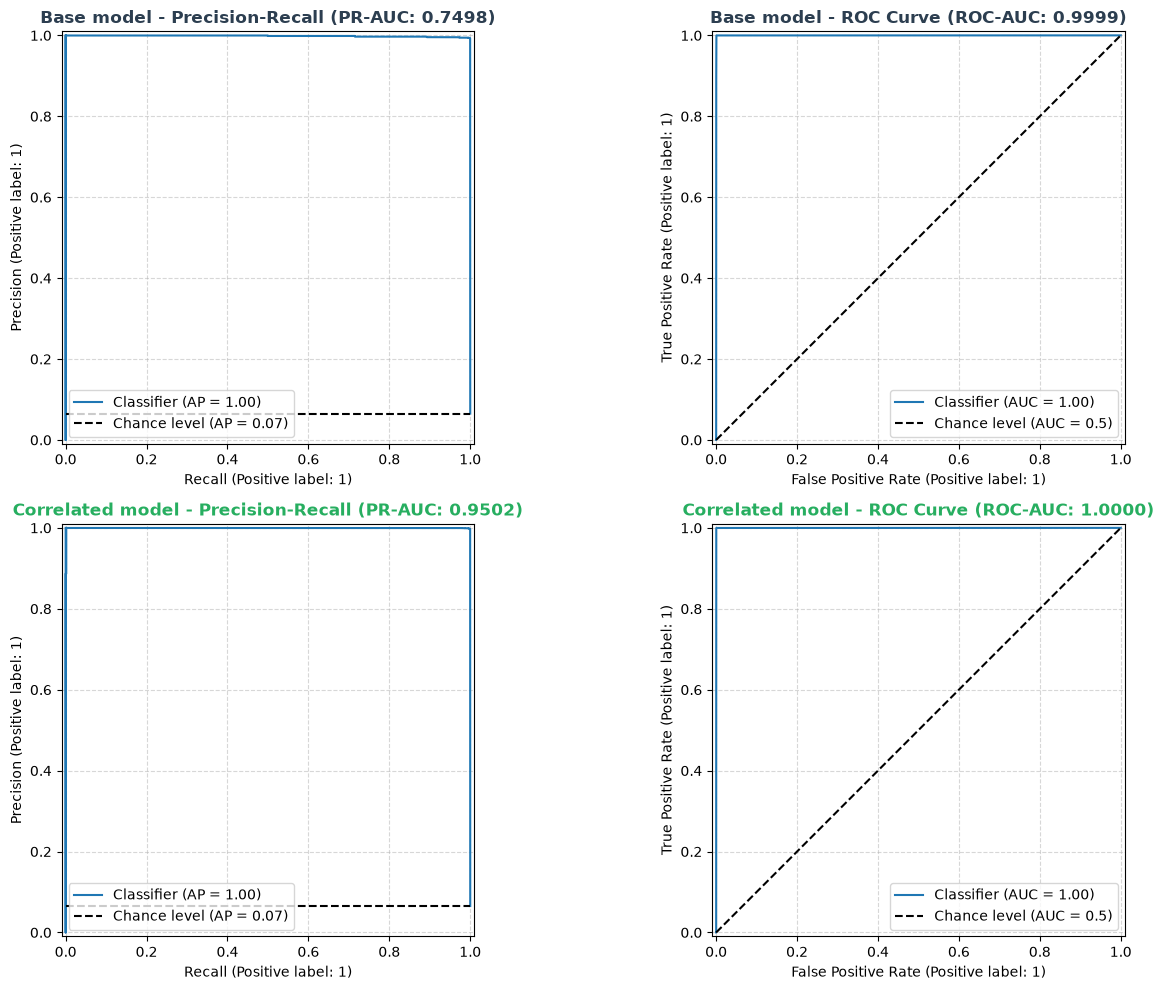

In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. PR Graph - Base
PrecisionRecallDisplay.from_predictions(
    y_test_base, 
    y_prob_base, 
    ax=axes[0, 0],
    plot_chance_level=True
)
axes[0, 0].set_title(f"Base model - Precision-Recall (PR-AUC: {pr_base:.4f})", fontweight="bold", color="#2c3e50")
axes[0, 0].grid(True, linestyle="--", alpha=0.5)

# 2. ROC Graph - Base
RocCurveDisplay.from_predictions(
    y_test_base, 
    y_prob_base, 
    ax=axes[0, 1],
    plot_chance_level=True
)
axes[0, 1].set_title(f"Base model - ROC Curve (ROC-AUC: {roc_base:.4f})", fontweight="bold", color="#2c3e50")
axes[0, 1].grid(True, linestyle="--", alpha=0.5)


# 3. PR Graph - Correlated
PrecisionRecallDisplay.from_predictions(
    y_test_corr, 
    y_prob_corr, 
    ax=axes[1, 0],
    plot_chance_level=True
)
axes[1, 0].set_title(f"Correlated model - Precision-Recall (PR-AUC: {pr_corr:.4f})", fontweight="bold", color="#27ae60")
axes[1, 0].grid(True, linestyle="--", alpha=0.5)

# 4. ROC Graph - Correlated
RocCurveDisplay.from_predictions(
    y_test_corr, 
    y_prob_corr, 
    ax=axes[1, 1],
    plot_chance_level=True
)
axes[1, 1].set_title(f"Correlated model - ROC Curve (ROC-AUC: {roc_corr:.4f})", fontweight="bold", color="#27ae60")
axes[1, 1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()



[INFO] Starting Preprocessing for CIC-IDS2017...]]
[INFO] Sequential correlation enabled (Window Size: 50)]]
[INFO] Stratified data splitting (80/20)...]]
[INFO] RobustScaler on the features...]]
[INFO] Preprocessing completed -> Train: (800, 27), Test: (200, 27)]]
--- TOP 15 FEATURES BY INFORMATION GAIN ---
 1. [BASE]       Packet Length Mean                  -> Gain: 20533472.70 | Splits: 190
 2. [CORRELATED] corr_avg_fwd_pkt_std_w50            -> Gain: 11616661.49 | Splits: 439
 3. [BASE]       Bwd Packet Length Mean              -> Gain: 4071736.04 | Splits: 116
 4. [BASE]       Fwd IAT Mean                        -> Gain: 1734072.83 | Splits: 131
 5. [BASE]       Packet Length Std                   -> Gain:  723146.65 | Splits: 84
 6. [BASE]       Bwd Packets/s                       -> Gain:  452355.86 | Splits: 118
 7. [BASE]       Flow IAT Std                        -> Gain:  270131.50 | Splits: 50
 8. [BASE]       Fwd IAT Std                         -> Gain:  225849.81 | Splits

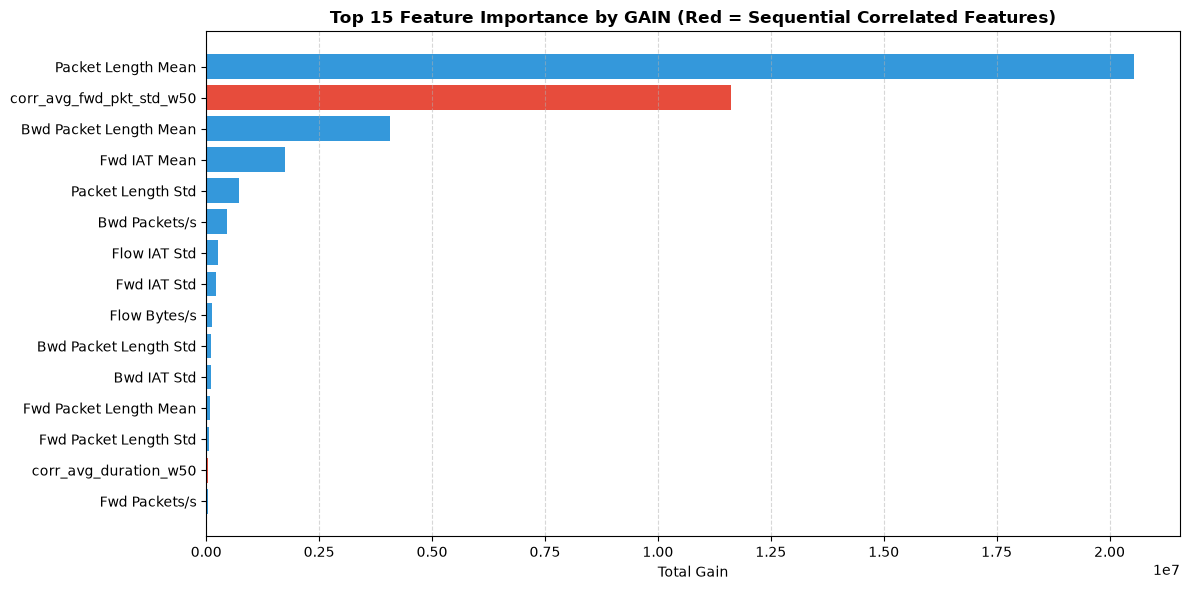

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import polars as pl
from cyber_recon_detector.features.preprocessor import ReconDataPreprocessor
from cyber_recon_detector.utils.terminal import TerminalLogger

logger = TerminalLogger()

preprocessor = ReconDataPreprocessor(logger=logger)
df_sample = pl.read_parquet(data_dir / "cicids2017_full.parquet", n_rows=1000)

_, _, _, _, feature_names = preprocessor.process_cicids2017(df_sample, use_correlation=True)

assert len(feature_names) == X_test_corr.shape[1], f"Mismatch: {len(feature_names)} nomi vs {X_test_corr.shape[1]} colonne in X_test"

booster = model_corr.booster_
gain_imp = booster.feature_importance(importance_type="gain")
split_imp = booster.feature_importance(importance_type="split")

df_imp = pl.DataFrame({
    "feature": feature_names,
    "gain": gain_imp,
    "splits": split_imp,
}).sort("gain", descending=True)

print("--- TOP 15 FEATURES BY INFORMATION GAIN ---")
for rank, row in enumerate(df_imp.head(15).iter_rows(named=True), 1):
    tag = "[CORRELATED]" if row["feature"].startswith("corr_") else "[BASE]"
    print(f"{rank:2d}. {tag:<12} {row['feature']:<35} -> Gain: {row['gain']:10.2f} | Splits: {row['splits']}")

# 5. Visualizzazione Grafica
df_top = df_imp.head(15).to_pandas()
colors = ["#e74c3c" if f.startswith("corr_") else "#3498db" for f in df_top["feature"]]

plt.figure(figsize=(12, 6))
plt.barh(df_top["feature"], df_top["gain"], color=colors)
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importance by GAIN (Red = Sequential Correlated Features)", fontsize=12, fontweight="bold")
plt.xlabel("Total Gain")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
